1. Import Library

In [18]:
# Mengimpor library untuk pengolahan data dan visualisasi.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Mengimpor library untuk mengakses Google Drive.
from google.colab import drive

# Mengimpor fungsi untuk pembagian data dan tuning model.
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

# Mengimpor model Decision Tree dan Random Forest.
from sklearn.tree import (
    DecisionTreeRegressor,
    plot_tree
)

from sklearn.ensemble import RandomForestRegressor

# Mengimpor metrik evaluasi regresi.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Mengabaikan warning agar output notebook lebih bersih.
warnings.filterwarnings("ignore")

# Mengatur tampilan visualisasi.
sns.set_theme(style="whitegrid")

# Menentukan random state agar hasil dapat direproduksi.
RANDOM_STATE = 42

2. Menghubungkan Google Drive

In [19]:
# Menghubungkan Google Colab dengan Google Drive.
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. Membaca Dataset

In [20]:
# Menentukan lokasi dataset.
path = (
    "/content/drive/MyDrive/"
    "SKRIPSI/dataset/raw/youtube_channel_data.csv"
)

# Membaca dataset.
df = pd.read_csv(path)

# Menampilkan informasi awal dataset.
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)

print("Jumlah baris :", len(df))
print("Jumlah kolom :", len(df.columns))

display(df.head())

INFORMASI DATASET
Jumlah baris : 5654
Jumlah kolom : 7


,VideoID,Title,UploadDate,Views,Likes,Dislikes,Comments
0,3UMBcd3TyhQ,What is SEO (Search Engine Optimization) & How...,2015-08-22 14:25:10+00:00,419504,3713,NaN,295
1,8RvAdYyvtcM,SEO Tutorial - What is Search Engine Working |...,2015-09-06 13:50:41+00:00,147843,1061,NaN,76
2,O6RZPzYxMls,"TYPES OF SEO: White Hat, Grey Hat & Black Hat ...",2015-09-19 08:25:17+00:00,127662,1082,NaN,48
3,nmX-C9emvEs,On-Page SEO: Big Guide to On-Page Optimization...,2015-09-19 10:38:26+00:00,248356,2389,NaN,256
4,2IXS-B_Zafk,Google Keyword Planner Tutorial - What is Keyw...,2015-09-25 19:01:11+00:00,135444,1429,NaN,310


4. Melihat Kolom Dataset

In [21]:
# Menampilkan seluruh nama kolom pada dataset.
print("=" * 60)
print("DAFTAR KOLOM")
print("=" * 60)

for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

DAFTAR KOLOM
1. VideoID
2. Title
3. UploadDate
4. Views
5. Likes
6. Dislikes
7. Comments


5. Pemeriksaan Missing Value

In [22]:
# Memeriksa jumlah missing value pada setiap kolom.
print("=" * 60)
print("MISSING VALUE")
print("=" * 60)

display(
    df.isnull().sum().to_frame(
        "Jumlah Missing"
    )
)

MISSING VALUE


,Jumlah Missing
VideoID,0
Title,0
UploadDate,0
Views,0
Likes,0
Dislikes,5654
Comments,0


6. Pemeriksaan Data Duplikat

In [23]:
# Memeriksa jumlah data yang memiliki baris duplikat.
print("=" * 60)
print("DATA DUPLIKAT")
print("=" * 60)

print(
    "Jumlah data duplikat :",
    df.duplicated().sum()
)

DATA DUPLIKAT
Jumlah data duplikat : 0


7. Statistik Deskriptif

In [24]:
# Menampilkan statistik deskriptif dataset.
display(
    df.describe(include="all").T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
VideoID,5654,5654,iQhhJ4HJeqQ,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,5654,5618,Kaun Banega Programmer | Html Interview Round ...,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UploadDate,5654,5653,2021-04-02 02:30:02+00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Views,5654.0,NaN,NaN,NaN,66834.662363,403388.468837,105.0,5868.0,15376.0,43910.5,22545031.0
Likes,5654.0,NaN,NaN,NaN,1577.990803,10739.938049,4.0,143.0,372.0,929.0,587547.0
Dislikes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comments,5654.0,NaN,NaN,NaN,45.169261,198.217977,0.0,6.0,15.0,34.0,7414.0


8. Data Cleaning

In [25]:

df_model = df[
    df["Views"] > 0
].copy()

print("=" * 60)
print("FILTER DATA")
print("=" * 60)

print("Data awal    :", len(df))
print("Data setelah :", len(df_model))

FILTER DATA
Data awal    : 5654
Data setelah : 5654


9. Membentuk Engagement Rate

In [26]:
# Menghitung Engagement Rate berdasarkan Likes, Comments, dan Views.
df_model["engagement_rate"] = (
    (
        df_model["Likes"] +
        df_model["Comments"]
    )
    / df_model["Views"]
) * 100

# Menampilkan hasil pembentukan Engagement Rate.
display(
    df_model[
        [
            "Views",
            "Likes",
            "Comments",
            "engagement_rate"
        ]
    ].head()
)

,Views,Likes,Comments,engagement_rate
0,419504,3713,295,0.955414
1,147843,1061,76,0.769059
2,127662,1082,48,0.885150
3,248356,2389,256,1.065003
4,135444,1429,310,1.283925


10. Statistik Engagement Rate

In [27]:
# Menampilkan statistik deskriptif Engagement Rate.
print("=" * 60)
print("STATISTIK ENGAGEMENT RATE")
print("=" * 60)

display(
    df_model["engagement_rate"]
    .describe()
    .to_frame()
    .T
)

STATISTIK ENGAGEMENT RATE


,count,mean,std,min,25%,50%,75%,max
engagement_rate,5654.0,2.687891,1.534125,0.048724,1.654926,2.298395,3.232274,15.594571


11. Distribusi Engagement Rate

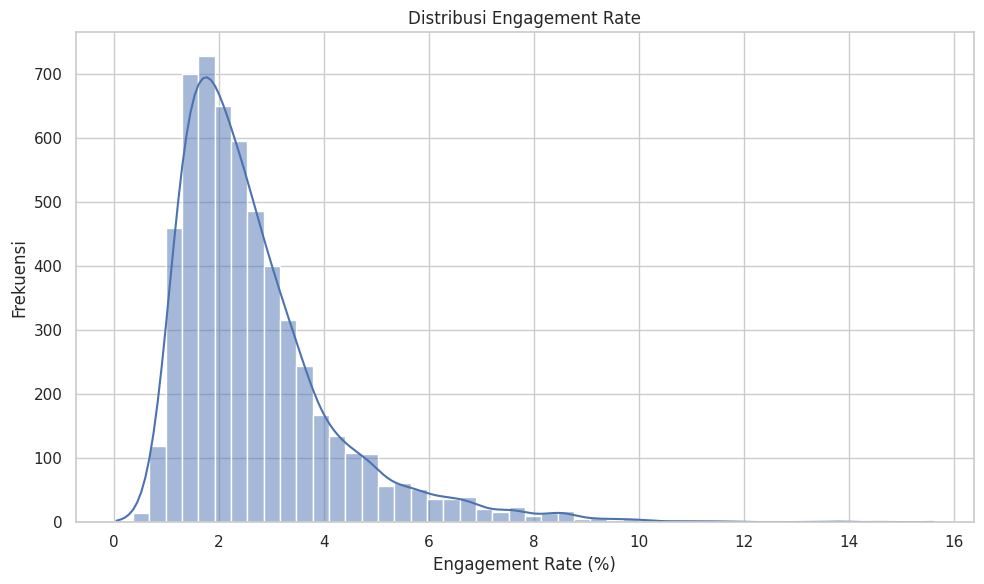

In [28]:
# Menampilkan distribusi Engagement Rate.
plt.figure(figsize=(10, 6))

sns.histplot(
    df_model["engagement_rate"],
    bins=50,
    kde=True
)

plt.title(
    "Distribusi Engagement Rate"
)

plt.xlabel(
    "Engagement Rate (%)"
)

plt.ylabel(
    "Frekuensi"
)

plt.tight_layout()
plt.show()

12. Feature Engineering

In [29]:
# Menghitung panjang judul video.
df_model["title_length"] = (
    df_model["Title"]
    .fillna("")
    .astype(str)
    .str.len()
)

# Mengubah UploadDate menjadi format tanggal.
df_model["UploadDate"] = pd.to_datetime(
    df_model["UploadDate"],
    errors="coerce"
)

# Mengambil jam publikasi video.
df_model["publish_hour"] = (
    df_model["UploadDate"].dt.hour
)

# Menentukan tanggal referensi berdasarkan tanggal publikasi maksimum.
reference_date = df_model["UploadDate"].max()

# Menghitung usia video dalam satuan hari.
df_model["video_age"] = (
    reference_date -
    df_model["UploadDate"]
).dt.days

13. Melihat Hasil Feature Engineering

In [30]:
# Menampilkan hasil pembentukan fitur.
display(
    df_model[
        [
            "Title",
            "UploadDate",
            "title_length",
            "publish_hour",
            "video_age"
        ]
    ].head()
)

print(
    "Tanggal referensi :",
    reference_date
)

,Title,UploadDate,title_length,publish_hour,video_age
0,What is SEO (Search Engine Optimization) & How...,2015-08-22 14:25:10+00:00,89,14,3626
1,SEO Tutorial - What is Search Engine Working |...,2015-09-06 13:50:41+00:00,75,13,3611
2,"TYPES OF SEO: White Hat, Grey Hat & Black Hat ...",2015-09-19 08:25:17+00:00,62,8,3599
3,On-Page SEO: Big Guide to On-Page Optimization...,2015-09-19 10:38:26+00:00,66,10,3599
4,Google Keyword Planner Tutorial - What is Keyw...,2015-09-25 19:01:11+00:00,73,19,3592


Tanggal referensi : 2025-07-27 13:30:39+00:00


14. Menentukan Fitur dan Target

In [31]:
# Menentukan variabel prediktor.
feature_columns = [
    "title_length",
    "publish_hour",
    "video_age"
]

# Menentukan variabel target.
target_column = "engagement_rate"

# Membentuk data fitur.
X = df_model[
    feature_columns
].copy()

# Membentuk data target.
y = df_model[
    target_column
].copy()

print("=" * 60)
print("VARIABEL PENELITIAN")
print("=" * 60)

for i, feature in enumerate(
    feature_columns, 1
):
    print(f"X{i} = {feature}")

print("\nTarget =", target_column)

VARIABEL PENELITIAN
X1 = title_length
X2 = publish_hour
X3 = video_age

Target = engagement_rate


15. Menghapus Missing Value pada Data Model

In [32]:
# Menggabungkan fitur dan target untuk pemeriksaan missing value.
data_model = pd.concat(
    [X, y],
    axis=1
).dropna()

# Memisahkan kembali fitur dan target.
X = data_model[
    feature_columns
].copy()

y = data_model[
    target_column
].copy()

print(
    "Jumlah data setelah preprocessing :",
    len(data_model)
)

Jumlah data setelah preprocessing : 5654


In [33]:
# Menyimpan dataset final setelah preprocessing dan feature engineering

dataset_final = df_model.loc[
    data_model.index
].copy()

output_path = (
    "/content/drive/MyDrive/"
    "SKRIPSI/dataset_final.csv"
)

dataset_final.to_csv(
    output_path,
    index=False
)

print("=" * 60)
print("DATASET FINAL BERHASIL DISIMPAN")
print("=" * 60)
print("Jumlah data  :", len(dataset_final))
print("Jumlah kolom :", len(dataset_final.columns))
print("Lokasi file  :", output_path)

display(dataset_final.head(10))

DATASET FINAL BERHASIL DISIMPAN
Jumlah data  : 5654
Jumlah kolom : 11
Lokasi file  : /content/drive/MyDrive/SKRIPSI/dataset_final.csv


,VideoID,Title,UploadDate,Views,Likes,Dislikes,Comments,engagement_rate,title_length,publish_hour,video_age
0,3UMBcd3TyhQ,What is SEO (Search Engine Optimization) & How...,2015-08-22 14:25:10+00:00,419504,3713,NaN,295,0.955414,89,14,3626
1,8RvAdYyvtcM,SEO Tutorial - What is Search Engine Working |...,2015-09-06 13:50:41+00:00,147843,1061,NaN,76,0.769059,75,13,3611
2,O6RZPzYxMls,"TYPES OF SEO: White Hat, Grey Hat & Black Hat ...",2015-09-19 08:25:17+00:00,127662,1082,NaN,48,0.885150,62,8,3599
3,nmX-C9emvEs,On-Page SEO: Big Guide to On-Page Optimization...,2015-09-19 10:38:26+00:00,248356,2389,NaN,256,1.065003,66,10,3599
4,2IXS-B_Zafk,Google Keyword Planner Tutorial - What is Keyw...,2015-09-25 19:01:11+00:00,135444,1429,NaN,310,1.283925,73,19,3592
5,LtK-IJU5_R8,Tag Optimization | Meta Tag Optimization | Met...,2015-10-04 13:35:42+00:00,75909,645,NaN,70,0.941917,71,13,3583
6,l2UbaPlI_5U,How to create a sitemap for a website | what i...,2015-10-09 15:33:13+00:00,66666,387,NaN,53,0.660007,86,15,3578
7,40hlRN0paks,How to create a Robot.txt | what is a Robots.t...,2015-10-17 09:45:15+00:00,58469,392,NaN,46,0.749115,85,9,3571
8,EZtFZgpfJOw,How to submit sitemap to Google | Sitemap Subm...,2015-10-26 08:28:12+00:00,44194,210,NaN,39,0.563425,91,8,3562
9,jC7T0QByn7A,Working of Google Webmaster | Google Webmaster...,2015-11-05 14:51:55+00:00,47120,280,NaN,66,0.734295,78,14,3551


16. Statistik Deskriptif Variabel Penelitian

In [34]:
# Menampilkan statistik deskriptif variabel yang digunakan dalam model.
display(
    data_model[
        feature_columns +
        [target_column]
    ].describe().round(4)
)

,title_length,publish_hour,video_age,engagement_rate
count,5654.0000,5654.0000,5654.0000,5654.0000
mean,74.6701,10.7290,1359.2331,2.6879
std,14.3524,4.2604,626.0216,1.5341
min,22.0000,0.0000,0.0000,0.0487
25%,65.0000,7.0000,1019.0000,1.6549
50%,75.0000,13.0000,1390.5000,2.2984
75%,86.0000,14.0000,1723.7500,3.2323
max,100.0000,21.0000,3626.0000,15.5946


17. Matriks Korelasi

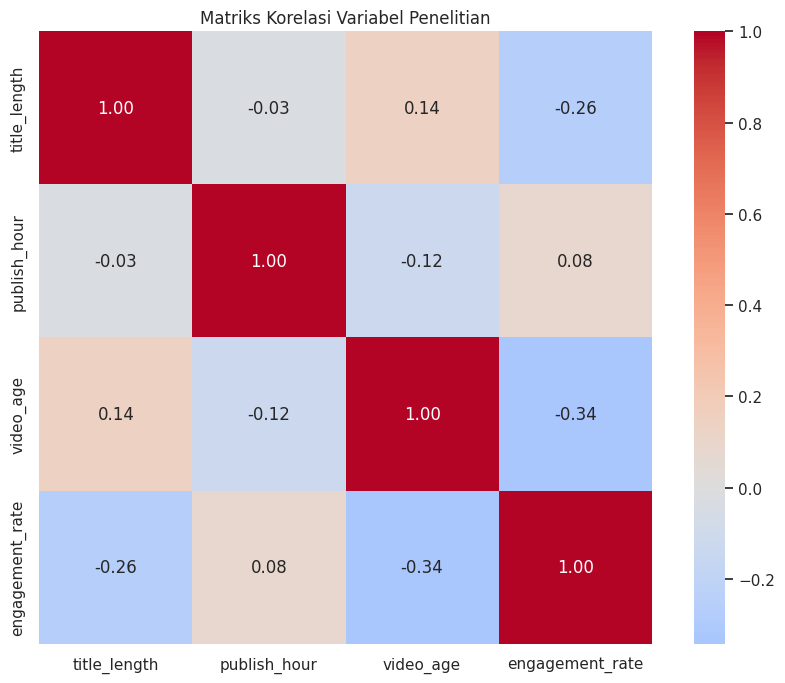

In [35]:
# Menghitung korelasi antarvariabel penelitian.
correlation = data_model[
    feature_columns +
    [target_column]
].corr()

# Menampilkan matriks korelasi.
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Matriks Korelasi Variabel Penelitian"
)

plt.tight_layout()
plt.show()

18. Pembagian Data Training dan Testing

In [36]:
# Membagi data menjadi 80% training dan 20% testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("=" * 60)
print("PEMBAGIAN DATA")
print("=" * 60)

print("Data keseluruhan :", len(X))
print("Data training    :", len(X_train))
print("Data testing     :", len(X_test))

PEMBAGIAN DATA
Data keseluruhan : 5654
Data training    : 4523
Data testing     : 1131


19. Tuning Decision Tree Regression

In [37]:
# Membuat model Decision Tree Regression.
dt_model = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

# Menentukan ruang pencarian hyperparameter Decision Tree.
dt_param = {
    "max_depth": [
        None, 5, 10, 15, 20, 25, 30
    ],

    "min_samples_split": [
        2, 5, 10, 15
    ],

    "min_samples_leaf": [
        1, 2, 4, 8
    ],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

# Melakukan pencarian hyperparameter menggunakan RandomizedSearchCV.
dt_search = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_param,
    n_iter=30,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Melatih proses tuning menggunakan data training.
dt_search.fit(
    X_train,
    y_train
)

print("=" * 60)
print("TUNING DECISION TREE REGRESSION")
print("=" * 60)

print("Parameter terbaik:")
print(dt_search.best_params_)

print(
    "\nCV R² terbaik :",
    dt_search.best_score_
)

TUNING DECISION TREE REGRESSION
Parameter terbaik:
{'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 10}

CV R² terbaik : 0.3753355344251115


20. Decision Tree Terbaik

In [38]:
# Mengambil model Decision Tree dengan parameter terbaik.
dt_best = dt_search.best_estimator_

print("=" * 60)
print("DECISION TREE REGRESSION TERBAIK")
print("=" * 60)

print(dt_best)

DECISION TREE REGRESSION TERBAIK
DecisionTreeRegressor(max_depth=10, min_samples_leaf=8, min_samples_split=10,
                      random_state=42)


21. Visualisasi Decision Tree

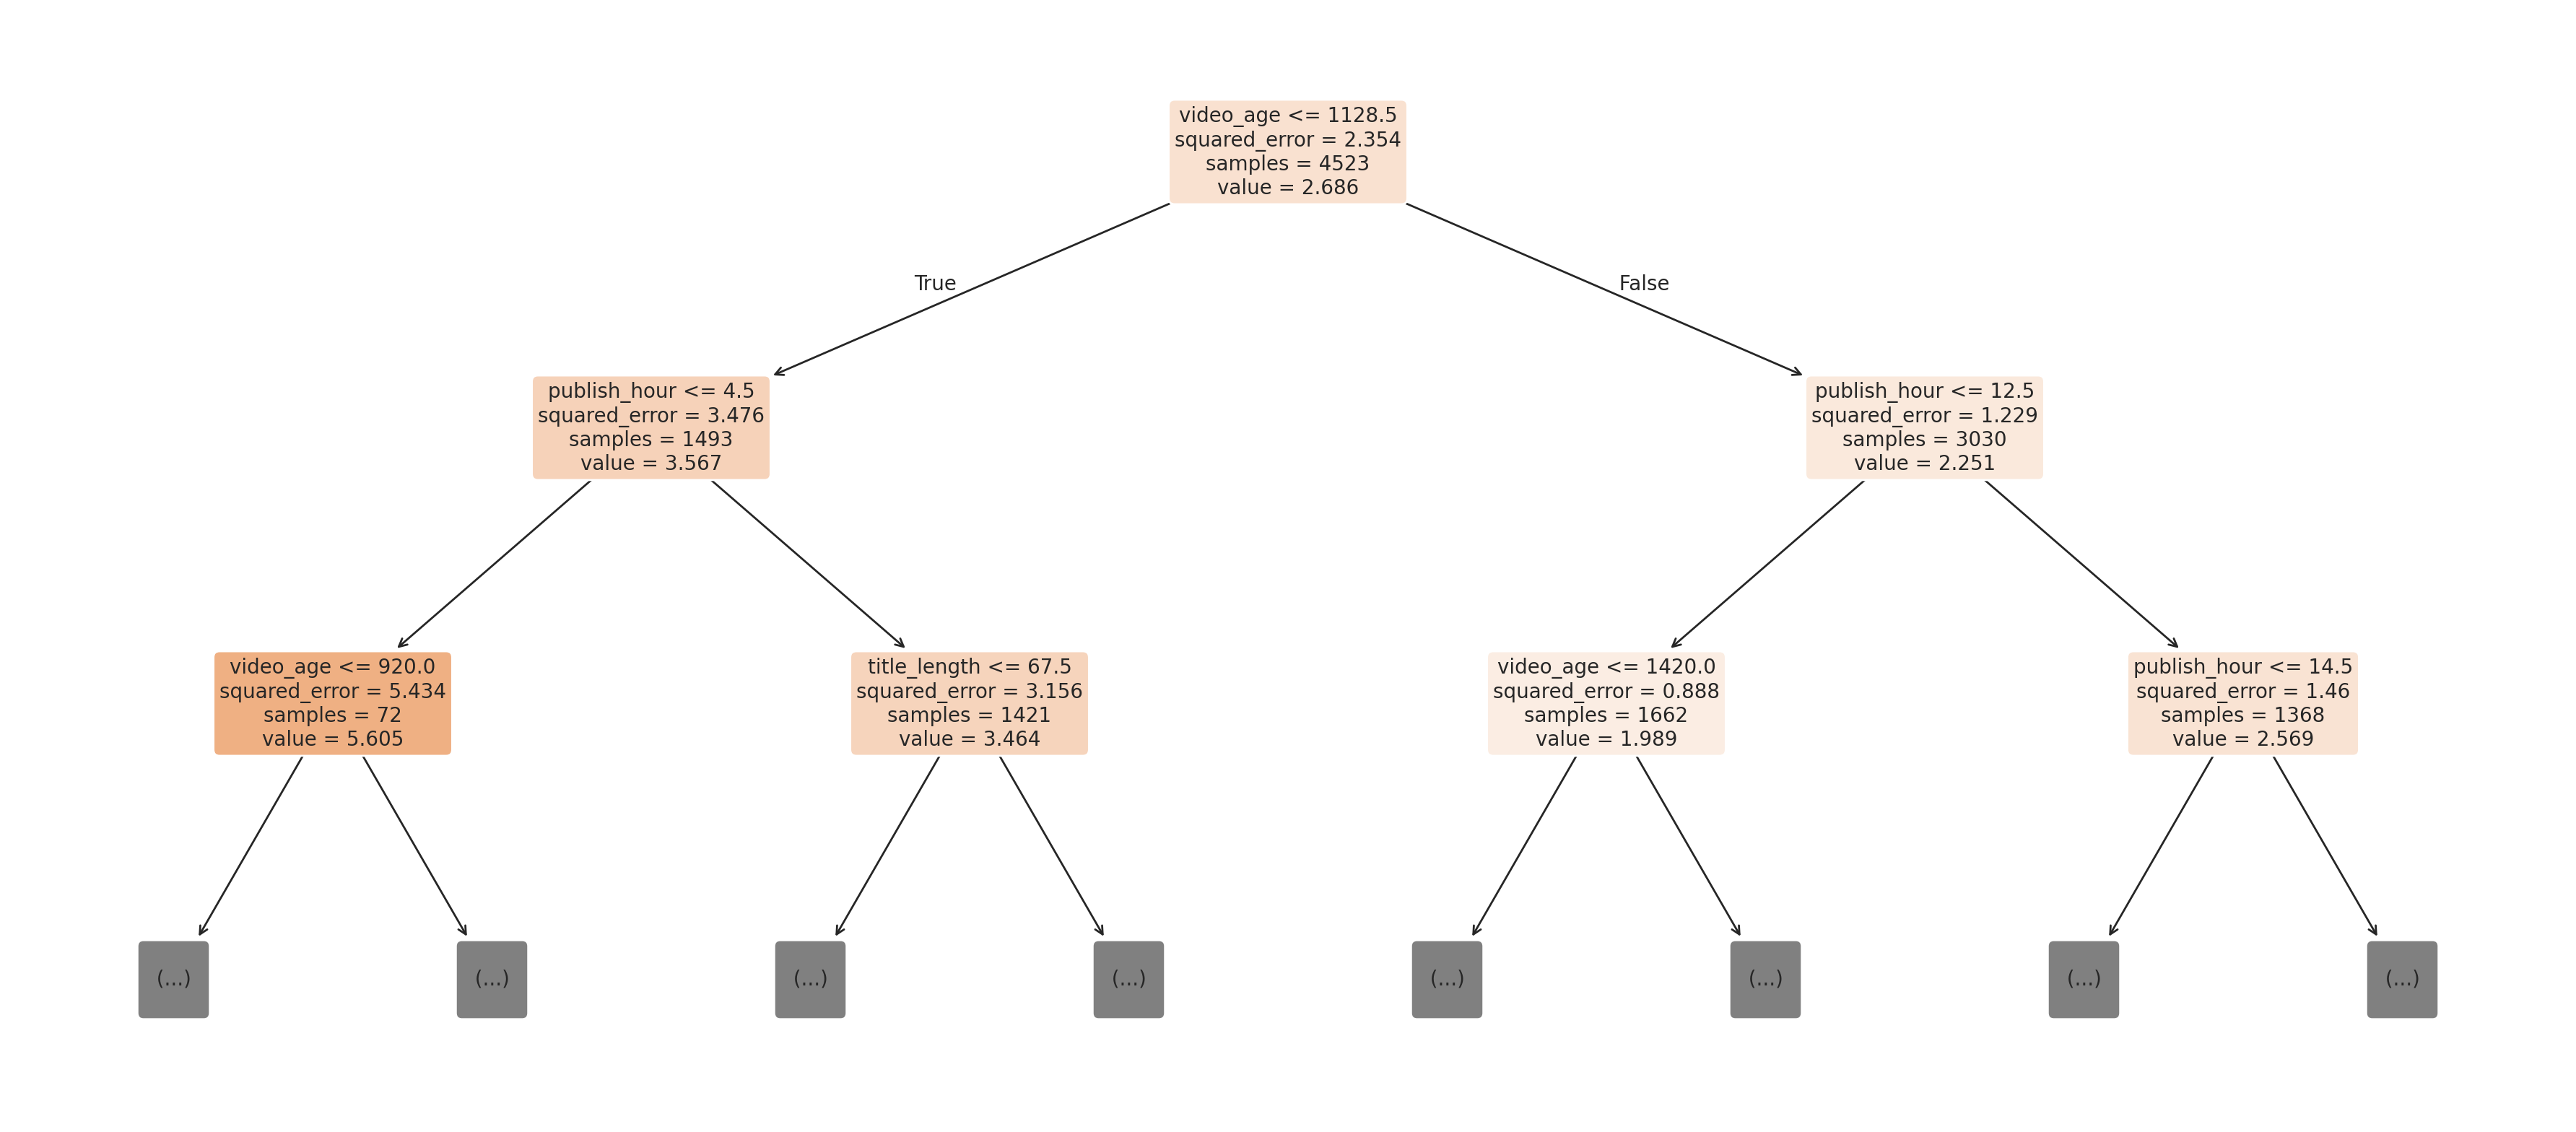

In [39]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8), dpi=200)

plot_tree(
    dt_best,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "decision_tree_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

22. Feature Importance Decision Tree

,Feature,Importance
2,video_age,0.634013
1,publish_hour,0.282152
0,title_length,0.083836


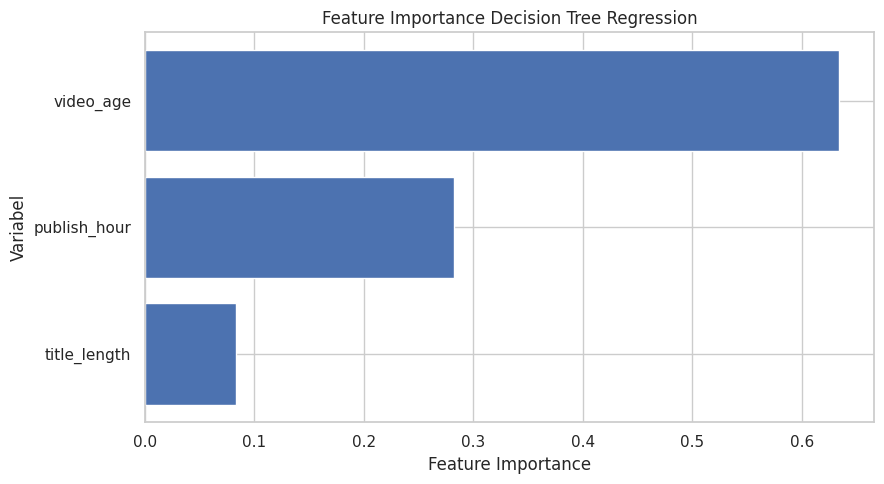

In [40]:
# Menghitung feature importance Decision Tree.
dt_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": dt_best.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

# Menampilkan feature importance.
display(
    dt_importance.sort_values(
        "Importance",
        ascending=False
    ).round(6)
)

# Membuat grafik feature importance.
plt.figure(figsize=(9, 5))

plt.barh(
    dt_importance["Feature"],
    dt_importance["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Variabel"
)

plt.title(
    "Feature Importance Decision Tree Regression"
)

plt.tight_layout()
plt.show()

23. Tuning Random Forest Regression

In [41]:
# Membuat model Random Forest Regression.
rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Menentukan ruang pencarian hyperparameter Random Forest.
rf_param = {
    "n_estimators": [
        100, 200, 300, 500
    ],

    "max_depth": [
        None, 5, 10, 15, 20, 25, 30
    ],

    "min_samples_split": [
        2, 5, 10, 15
    ],

    "min_samples_leaf": [
        1, 2, 4, 8
    ],

    "max_features": [
        1.0,
        "sqrt",
        "log2"
    ]
}

# Melakukan pencarian hyperparameter menggunakan RandomizedSearchCV.
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param,
    n_iter=30,
    cv=3,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Melatih proses tuning menggunakan data training.
rf_search.fit(
    X_train,
    y_train
)

print("=" * 60)
print("TUNING RANDOM FOREST REGRESSION")
print("=" * 60)

print("Parameter terbaik:")
print(rf_search.best_params_)

print(
    "\nCV R² terbaik :",
    rf_search.best_score_
)

TUNING RANDOM FOREST REGRESSION
Parameter terbaik:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 15}

CV R² terbaik : 0.47431228443203777


24. Random Forest Terbaik

In [42]:
# Mengambil model Random Forest dengan parameter terbaik.
rf_best = rf_search.best_estimator_

print("=" * 60)
print("RANDOM FOREST REGRESSION TERBAIK")
print("=" * 60)

print(rf_best)

RANDOM FOREST REGRESSION TERBAIK
RandomForestRegressor(max_depth=15, n_estimators=500, n_jobs=-1,
                      random_state=42)


25. Visualisasi Salah Satu Tree pada Random Forest

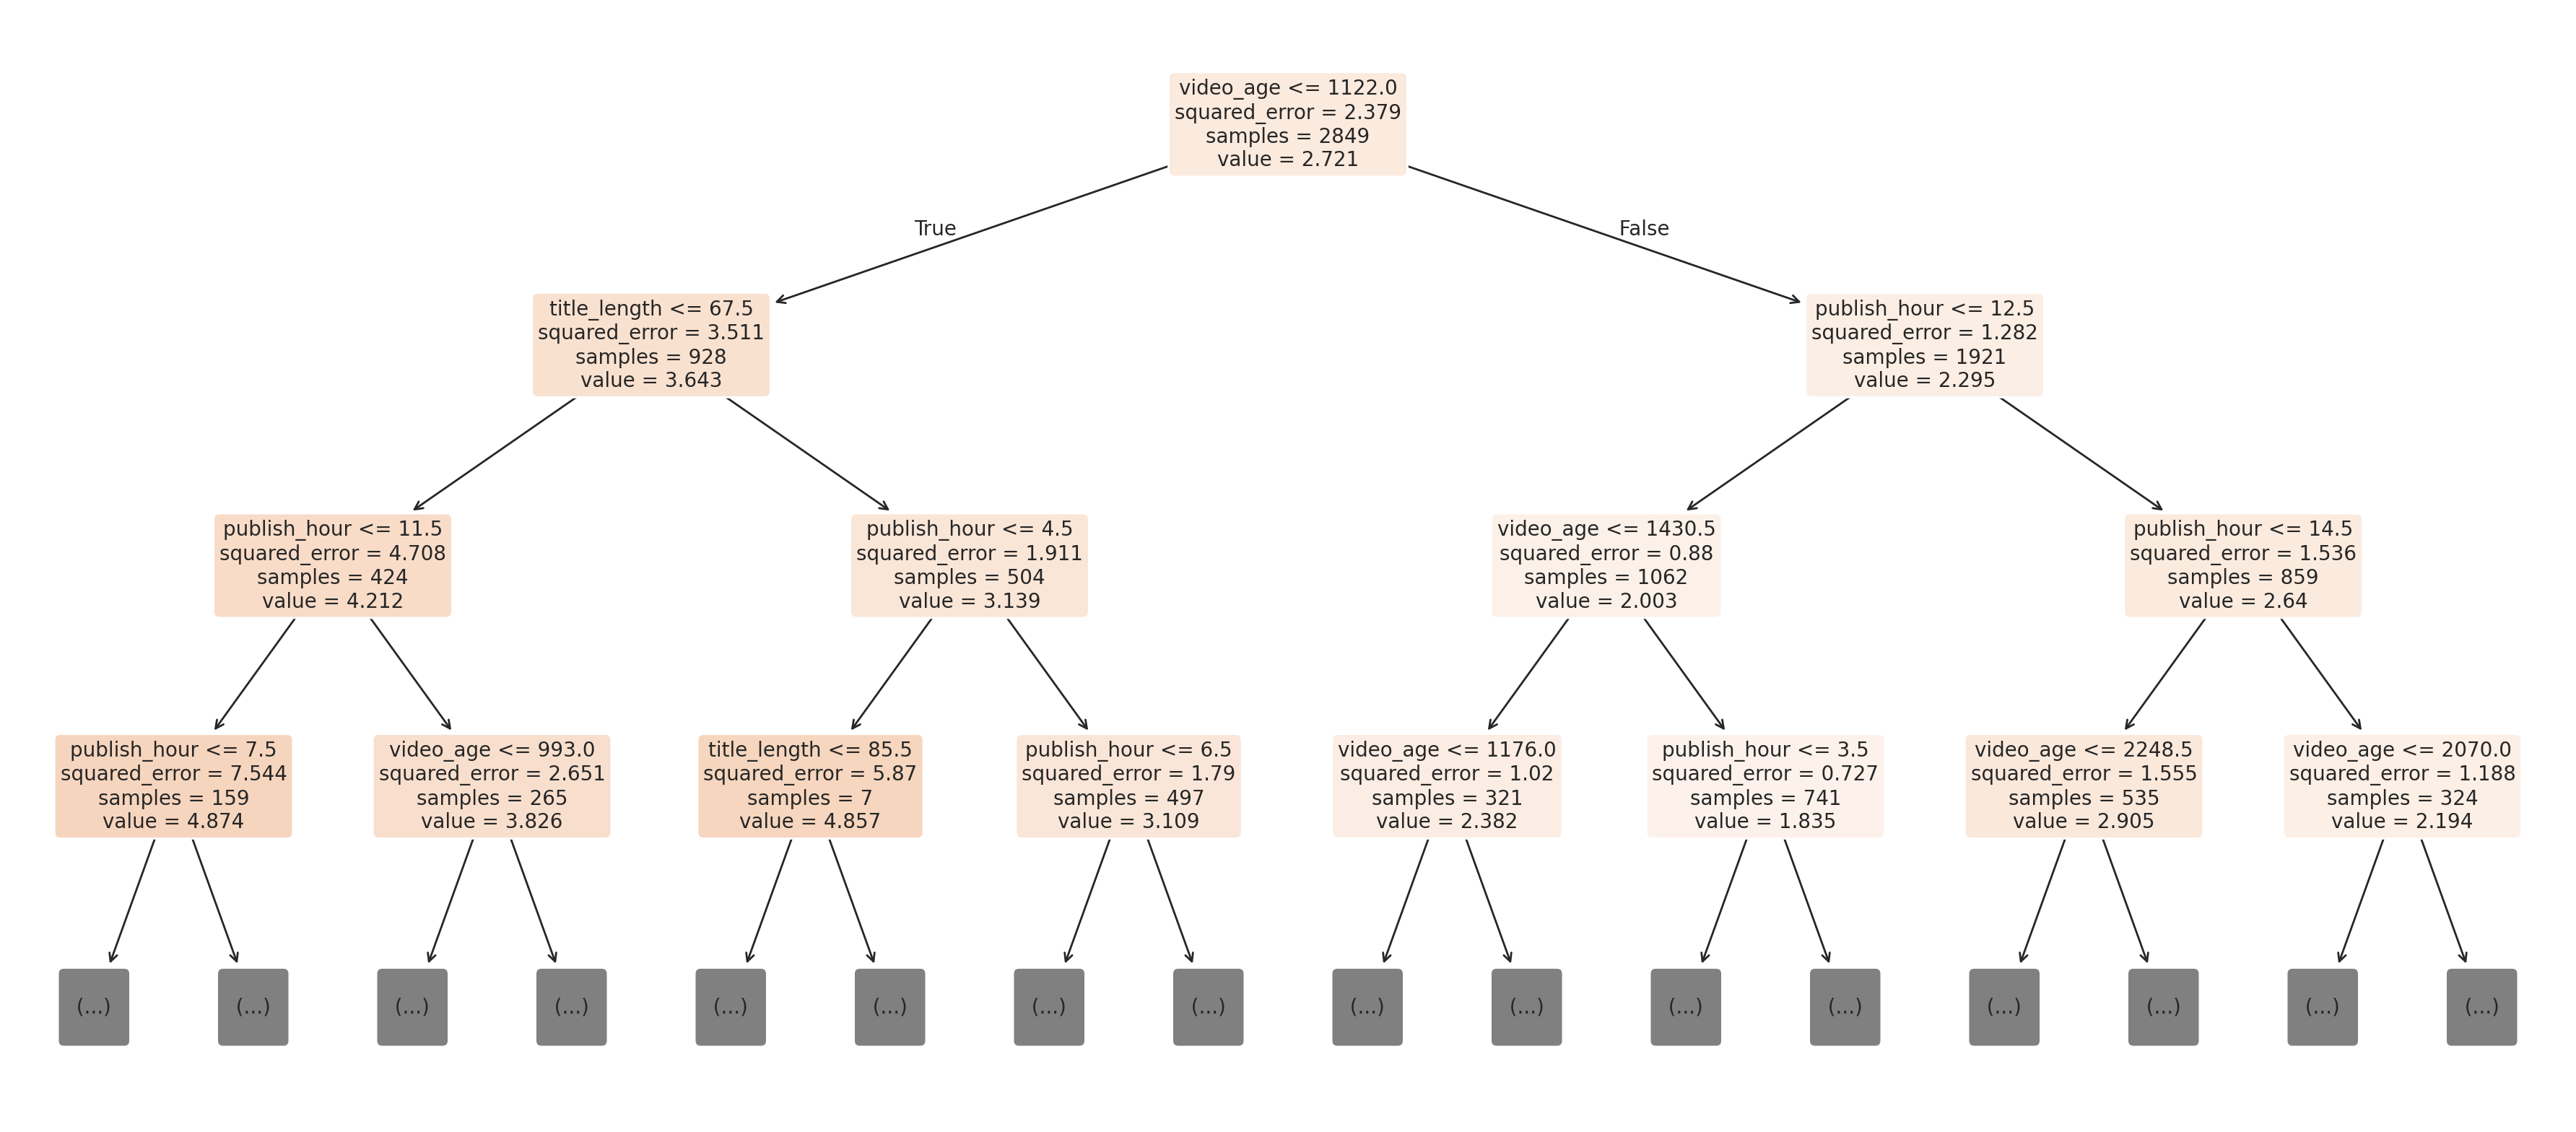

In [43]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8), dpi=200)

plot_tree(
    rf_best.estimators_[0],
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "random_forest_tree_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

26. Feature Importance Random Forest

,Feature,Importance
2,video_age,0.601472
1,publish_hour,0.212207
0,title_length,0.186321


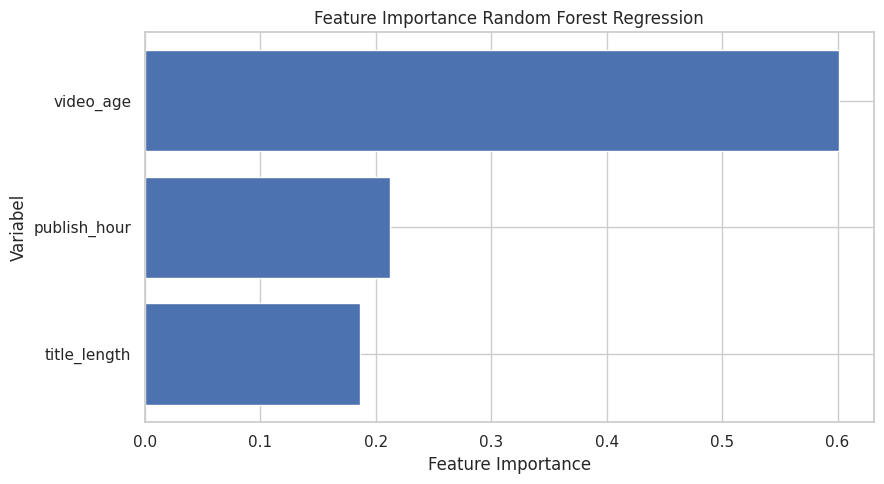

In [44]:
# Menghitung feature importance Random Forest.
rf_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_best.feature_importances_
}).sort_values(
    "Importance",
    ascending=True
)

# Menampilkan feature importance.
display(
    rf_importance.sort_values(
        "Importance",
        ascending=False
    ).round(6)
)

# Membuat grafik feature importance.
plt.figure(figsize=(9, 5))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Variabel"
)

plt.title(
    "Feature Importance Random Forest Regression"
)

plt.tight_layout()
plt.show()

27. Melakukan Prediksi

In [45]:
# Melakukan prediksi menggunakan Decision Tree.
y_pred_dt = dt_best.predict(
    X_test
)

# Melakukan prediksi menggunakan Random Forest.
y_pred_rf = rf_best.predict(
    X_test
)

print(
    "Prediksi Decision Tree dan Random Forest selesai."
)

Prediksi Decision Tree dan Random Forest selesai.


28. Fungsi Lima Metrik Evaluasi

In [46]:
# Membuat fungsi untuk menghitung lima metrik evaluasi.
def evaluasi_model(y_actual, y_pred):

    y_actual = np.asarray(y_actual)
    y_pred = np.asarray(y_pred)

    # Menghitung MAE.
    mae = mean_absolute_error(
        y_actual,
        y_pred
    )

    # Menghitung MSE.
    mse = mean_squared_error(
        y_actual,
        y_pred
    )

    # Menghitung RMSE.
    rmse = np.sqrt(mse)

    # Menghitung MAPE pada nilai aktual yang lebih dari nol.
    mask = y_actual > 0

    mape = mean_absolute_percentage_error(
        y_actual[mask],
        y_pred[mask]
    ) * 100

    # Menghitung R².
    r2 = r2_score(
        y_actual,
        y_pred
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R²": r2
    }

29. Evaluasi Decision Tree

In [47]:
# Menghitung lima metrik evaluasi Decision Tree.
hasil_dt = evaluasi_model(
    y_test,
    y_pred_dt
)

print("=" * 60)
print("HASIL EVALUASI DECISION TREE")
print("=" * 60)

print(
    f"MAE  : {hasil_dt['MAE']:.6f}"
)

print(
    f"MSE  : {hasil_dt['MSE']:.6f}"
)

print(
    f"RMSE : {hasil_dt['RMSE']:.6f}"
)

print(
    f"MAPE : {hasil_dt['MAPE (%)']:.6f}%"
)

print(
    f"R²   : {hasil_dt['R²']:.6f}"
)

HASIL EVALUASI DECISION TREE
MAE  : 0.749828
MSE  : 1.469690
RMSE : 1.212308
MAPE : 29.579320%
R²   : 0.374315


30. Evaluasi Random Forest

In [48]:
# Menghitung lima metrik evaluasi Random Forest.
hasil_rf = evaluasi_model(
    y_test,
    y_pred_rf
)

print("=" * 60)
print("HASIL EVALUASI RANDOM FOREST")
print("=" * 60)

print(
    f"MAE  : {hasil_rf['MAE']:.6f}"
)

print(
    f"MSE  : {hasil_rf['MSE']:.6f}"
)

print(
    f"RMSE : {hasil_rf['RMSE']:.6f}"
)

print(
    f"MAPE : {hasil_rf['MAPE (%)']:.6f}%"
)

print(
    f"R²   : {hasil_rf['R²']:.6f}"
)

HASIL EVALUASI RANDOM FOREST
MAE  : 0.696671
MSE  : 1.235468
RMSE : 1.111516
MAPE : 26.947875%
R²   : 0.474029


31. Tabel Perbandingan Lima Metrik

In [49]:
# Membuat tabel perbandingan performa kedua model.
hasil_perbandingan = pd.DataFrame({
    "Model": [
        "Decision Tree Regression",
        "Random Forest Regression"
    ],

    "MAE": [
        hasil_dt["MAE"],
        hasil_rf["MAE"]
    ],

    "MSE": [
        hasil_dt["MSE"],
        hasil_rf["MSE"]
    ],

    "RMSE": [
        hasil_dt["RMSE"],
        hasil_rf["RMSE"]
    ],

    "MAPE (%)": [
        hasil_dt["MAPE (%)"],
        hasil_rf["MAPE (%)"]
    ],

    "R²": [
        hasil_dt["R²"],
        hasil_rf["R²"]
    ]
})

display(
    hasil_perbandingan.round(6)
)

,Model,MAE,MSE,RMSE,MAPE (%),R²
0,Decision Tree Regression,0.749828,1.469690,1.212308,29.579320,0.374315
1,Random Forest Regression,0.696671,1.235468,1.111516,26.947875,0.474029


32. Scatterplot Decision Tree

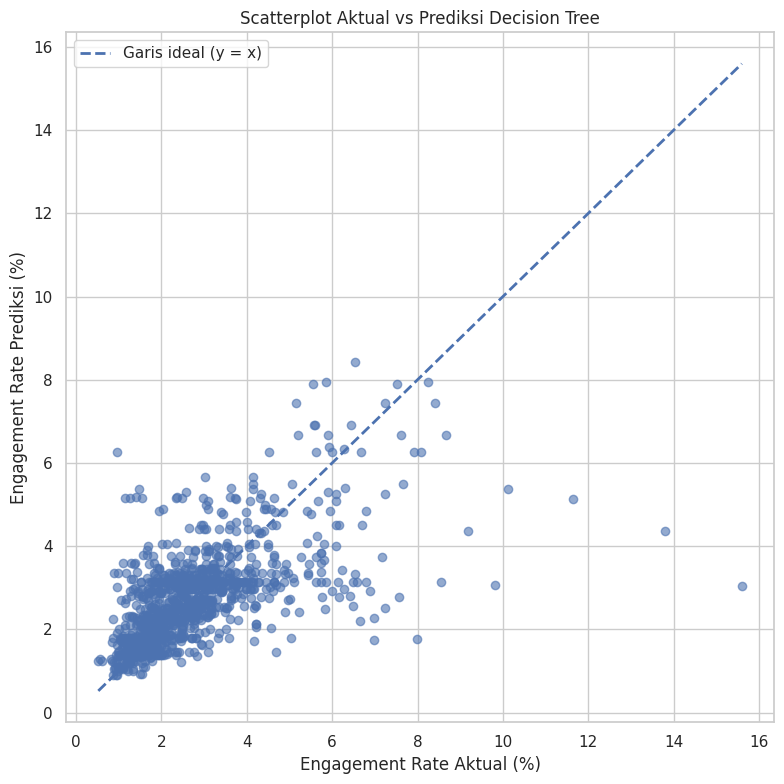

In [50]:
# Membuat scatterplot nilai aktual dan prediksi Decision Tree.
plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    y_test,
    y_pred_dt,
    alpha=0.6
)

# Membuat garis prediksi ideal.
min_value = min(
    y_test.min(),
    y_pred_dt.min()
)

max_value = max(
    y_test.max(),
    y_pred_dt.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Garis ideal (y = x)"
)

plt.xlabel(
    "Engagement Rate Aktual (%)"
)

plt.ylabel(
    "Engagement Rate Prediksi (%)"
)

plt.title(
    "Scatterplot Aktual vs Prediksi Decision Tree"
)

plt.legend()

plt.tight_layout()
plt.show()

33. Scatterplot Random Forest

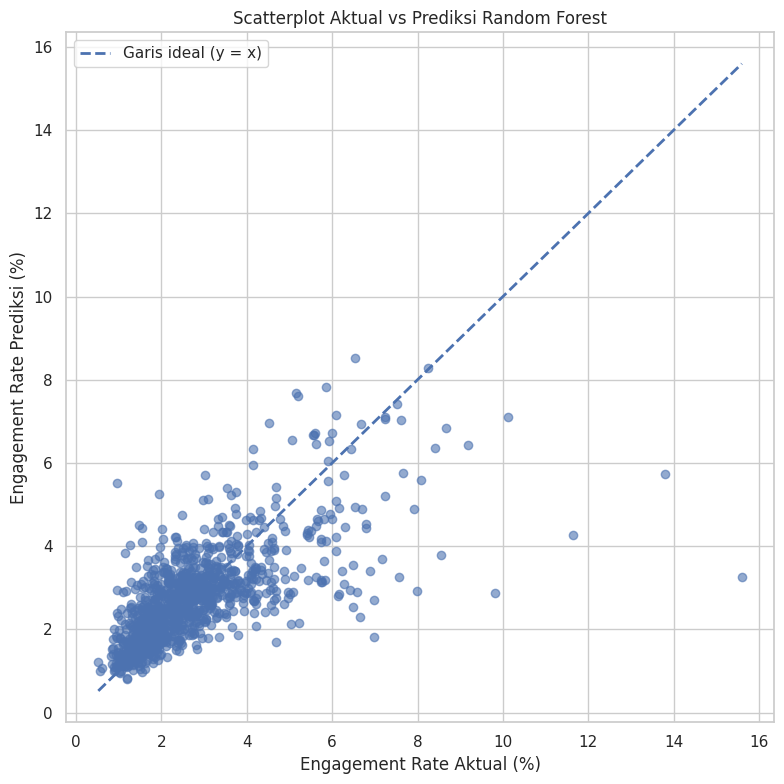

In [51]:
# Membuat scatterplot nilai aktual dan prediksi Random Forest.
plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

# Membuat garis prediksi ideal.
min_value = min(
    y_test.min(),
    y_pred_rf.min()
)

max_value = max(
    y_test.max(),
    y_pred_rf.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Garis ideal (y = x)"
)

plt.xlabel(
    "Engagement Rate Aktual (%)"
)

plt.ylabel(
    "Engagement Rate Prediksi (%)"
)

plt.title(
    "Scatterplot Aktual vs Prediksi Random Forest"
)

plt.legend()

plt.tight_layout()
plt.show()

34. Line Plot Decision Tree

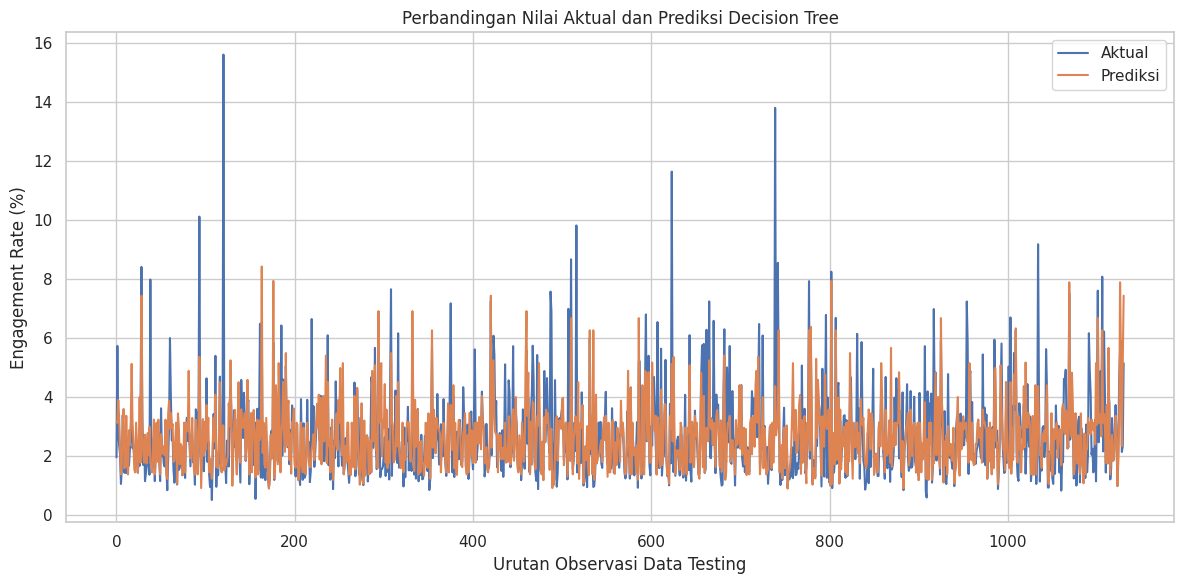

In [52]:
# Membuat line plot nilai aktual dan prediksi Decision Tree.
plot_dt = pd.DataFrame({
    "Aktual": y_test.to_numpy(),
    "Prediksi": y_pred_dt
}).reset_index(drop=True)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    plot_dt.index,
    plot_dt["Aktual"],
    label="Aktual",
    linewidth=1.5
)

plt.plot(
    plot_dt.index,
    plot_dt["Prediksi"],
    label="Prediksi",
    linewidth=1.5
)

plt.title(
    "Perbandingan Nilai Aktual dan Prediksi Decision Tree"
)

plt.xlabel(
    "Urutan Observasi Data Testing"
)

plt.ylabel(
    "Engagement Rate (%)"
)

plt.legend()

plt.tight_layout()
plt.show()

35. Line Plot Random Forest

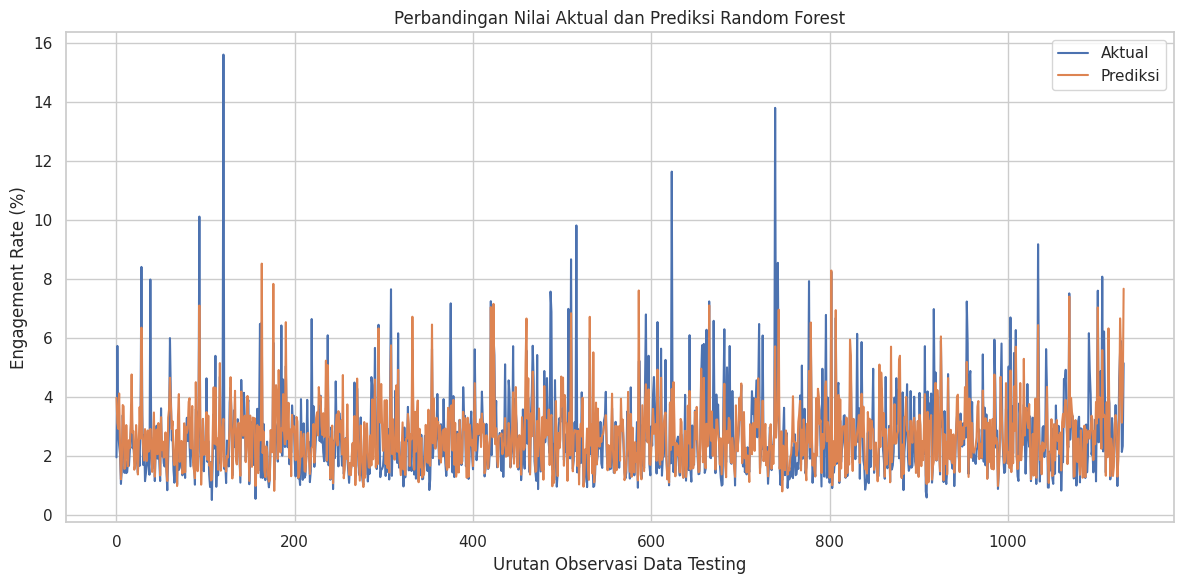

In [56]:
# Membuat line plot nilai aktual dan prediksi Random Forest.
plot_rf = pd.DataFrame({
    "Aktual": y_test.to_numpy(),
    "Prediksi": y_pred_rf
}).reset_index(drop=True)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    plot_rf.index,
    plot_rf["Aktual"],
    label="Aktual",
    linewidth=1.5
)

plt.plot(
    plot_rf.index,
    plot_rf["Prediksi"],
    label="Prediksi",
    linewidth=1.5
)

plt.title(
    "Perbandingan Nilai Aktual dan Prediksi Random Forest"
)

plt.xlabel(
    "Urutan Observasi Data Testing"
)

plt.ylabel(
    "Engagement Rate (%)"
)

plt.legend()

plt.tight_layout()
plt.show()

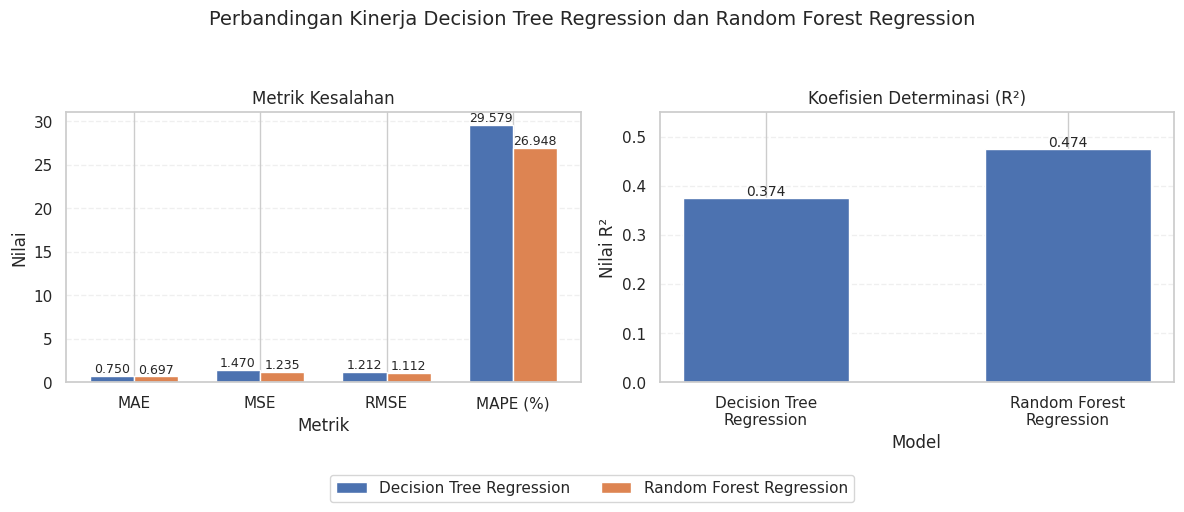

In [57]:
# Visualisasi Perbandingan Kinerja Decision Tree Regression
# dan Random Forest Regression

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# DATA METRIK
# ==========================================================

metrics_error = [
    "MAE",
    "MSE",
    "RMSE",
    "MAPE (%)"
]

decision_tree_error = [
    hasil_dt["MAE"],
    hasil_dt["MSE"],
    hasil_dt["RMSE"],
    hasil_dt["MAPE (%)"]
]

random_forest_error = [
    hasil_rf["MAE"],
    hasil_rf["MSE"],
    hasil_rf["RMSE"],
    hasil_rf["MAPE (%)"]
]

# R²
decision_tree_r2 = hasil_dt["R²"]
random_forest_r2 = hasil_rf["R²"]


# ==========================================================
# MEMBUAT FIGURE
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


# ==========================================================
# PANEL 1: METRIK KESALAHAN
# ==========================================================

x = np.arange(len(metrics_error))
width = 0.35

bars_dt = axes[0].bar(
    x - width / 2,
    decision_tree_error,
    width,
    label="Decision Tree Regression"
)

bars_rf = axes[0].bar(
    x + width / 2,
    random_forest_error,
    width,
    label="Random Forest Regression"
)

axes[0].set_title(
    "Metrik Kesalahan"
)

axes[0].set_xlabel(
    "Metrik"
)

axes[0].set_ylabel(
    "Nilai"
)

axes[0].set_xticks(
    x
)

axes[0].set_xticklabels(
    metrics_error
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Nilai pada bar Decision Tree
for bar in bars_dt:
    height = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Nilai pada bar Random Forest
for bar in bars_rf:
    height = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


# ==========================================================
# PANEL 2: R²
# ==========================================================

models = [
    "Decision Tree\nRegression",
    "Random Forest\nRegression"
]

r2_values = [
    decision_tree_r2,
    random_forest_r2
]

bars_r2 = axes[1].bar(
    models,
    r2_values,
    width=0.55
)

axes[1].set_title(
    "Koefisien Determinasi (R²)"
)

axes[1].set_xlabel(
    "Model"
)

axes[1].set_ylabel(
    "Nilai R²"
)

axes[1].set_ylim(
    0,
    0.55
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Nilai R²
for bar in bars_r2:
    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


# ==========================================================
# JUDUL UTAMA
# ==========================================================

fig.suptitle(
    "Perbandingan Kinerja Decision Tree Regression dan Random Forest Regression",
    fontsize=14
)

# Legend
fig.legend(
    ["Decision Tree Regression", "Random Forest Regression"],
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(
    rect=[0, 0.06, 1, 0.93]
)

plt.show()